<a href="https://colab.research.google.com/github/badaraaliouguindo/energy-consumption-forecast/blob/main/notebooks/01_EDA_Energy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

print("Librairies chargées !")

Librairies chargées !


# Chargement et préparation

In [7]:
df = pd.read_csv('AEP_hourly.csv')

# Conversion de la colonne date en datetime
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')
df = df.sort_index()

print("Shape :", df.shape)
print("\nPériode couverte :")
print(f"  Du  : {df.index.min()}")
print(f"  Au  : {df.index.max()}")
print(f"  Soit : {(df.index.max() - df.index.min()).days // 365} ans de données")
print("\nAperçu :")
df.head()

Shape : (121273, 1)

Période couverte :
  Du  : 2004-10-01 01:00:00
  Au  : 2018-08-03 00:00:00
  Soit : 13 ans de données

Aperçu :


,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


# Visualisation globale

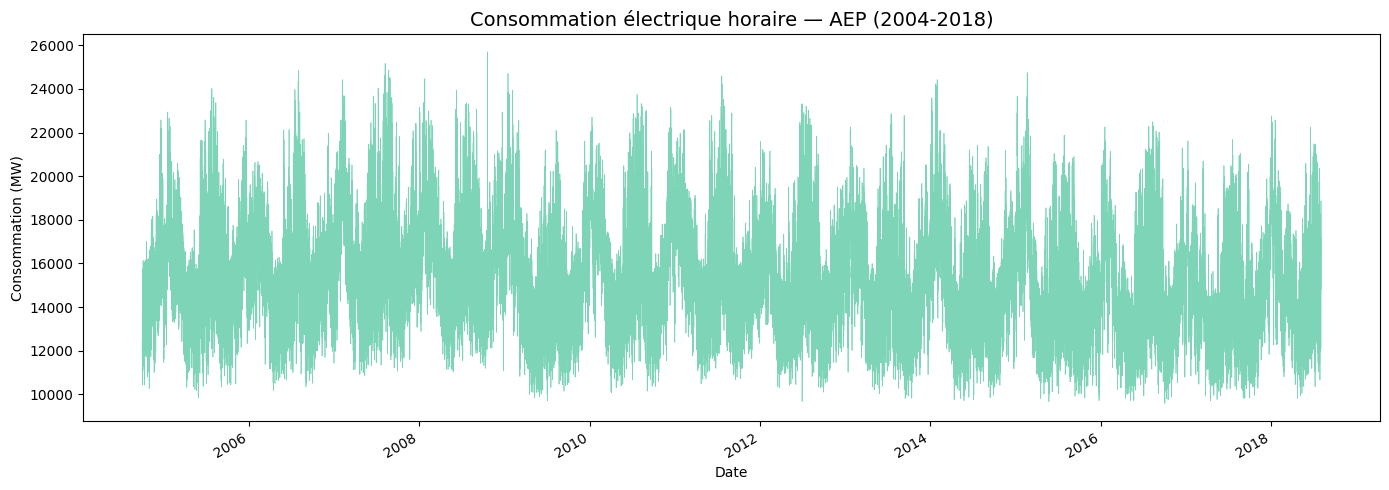

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
df['AEP_MW'].plot(ax=ax, color='#5DCAA5', linewidth=0.5, alpha=0.8)
ax.set_title("Consommation électrique horaire — AEP (2004-2018)", fontsize=14)
ax.set_ylabel("Consommation (MW)")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

# Agrégation mensuelle (plus lisible)

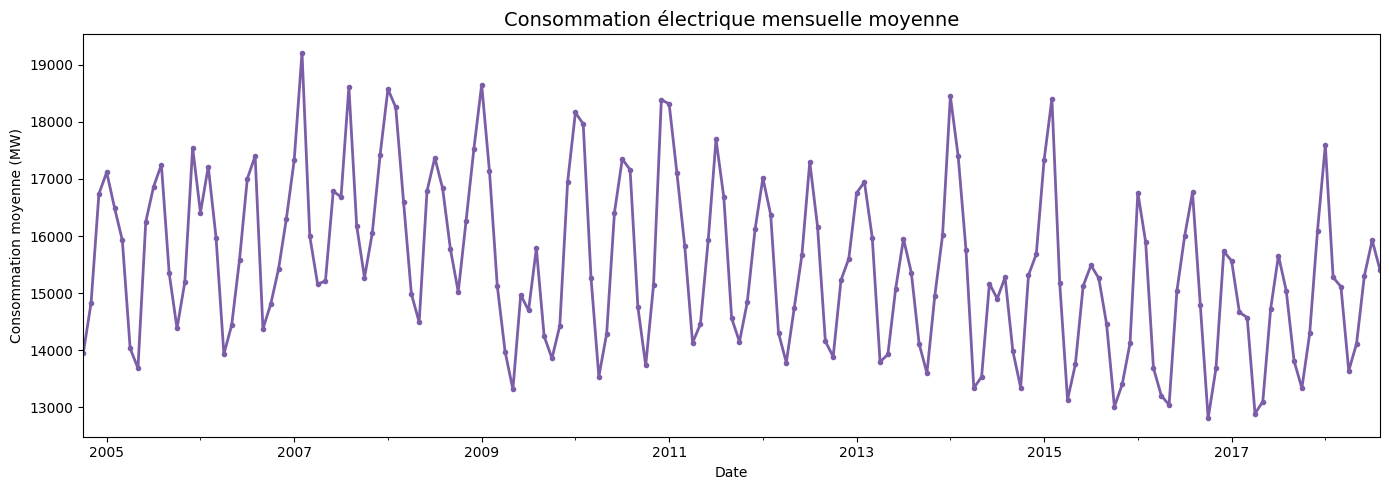

Consommation moyenne globale : 15500.0 MW
Consommation max : 25695.0 MW
Consommation min : 9581.0 MW


In [9]:
# On agrège par mois pour mieux voir les tendances
df_monthly = df['AEP_MW'].resample('ME').mean()

fig, ax = plt.subplots(figsize=(14, 5))
df_monthly.plot(ax=ax, color='#7B5EA7', linewidth=2, marker='o', markersize=3)
ax.set_title("Consommation électrique mensuelle moyenne", fontsize=14)
ax.set_ylabel("Consommation moyenne (MW)")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

print("Consommation moyenne globale :", round(df['AEP_MW'].mean(), 0), "MW")
print("Consommation max :", round(df['AEP_MW'].max(), 0), "MW")
print("Consommation min :", round(df['AEP_MW'].min(), 0), "MW")

# Patterns horaires et hebdomadaires

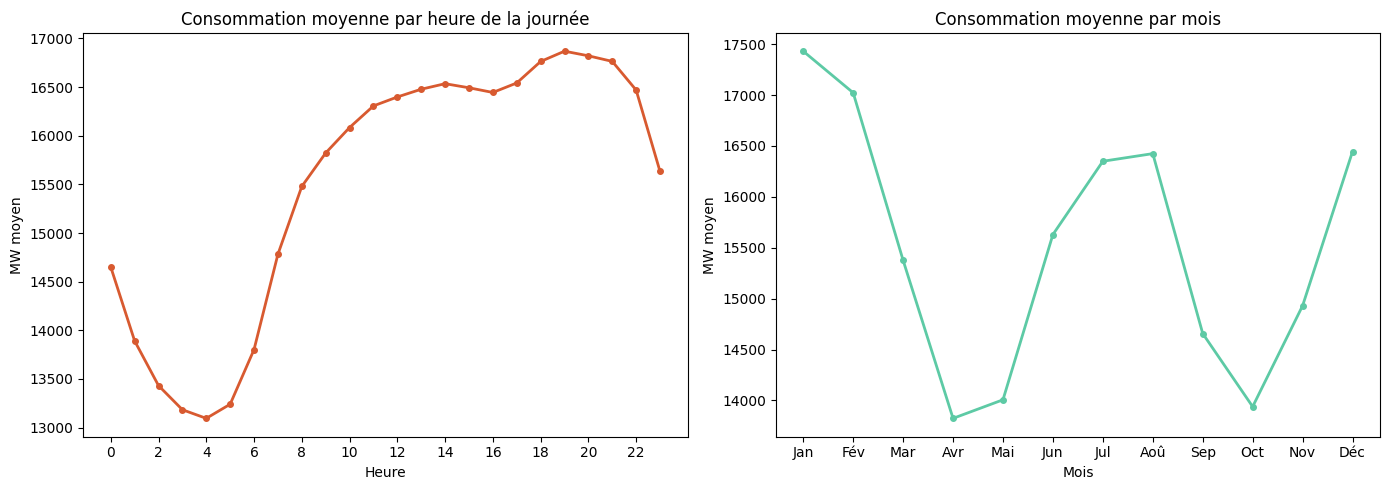

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pattern par heure de la journée
df.groupby(df.index.hour)['AEP_MW'].mean().plot(
    ax=axes[0], color='#D85A30', linewidth=2, marker='o', markersize=4
)
axes[0].set_title("Consommation moyenne par heure de la journée")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("MW moyen")
axes[0].set_xticks(range(0, 24, 2))

# Pattern par mois de l'année
df.groupby(df.index.month)['AEP_MW'].mean().plot(
    ax=axes[1], color='#5DCAA5', linewidth=2, marker='o', markersize=4
)
axes[1].set_title("Consommation moyenne par mois")
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("MW moyen")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Fév','Mar','Avr','Mai','Jun',
                          'Jul','Aoû','Sep','Oct','Nov','Déc'])

plt.tight_layout()
plt.show()

# Décomposition de la série

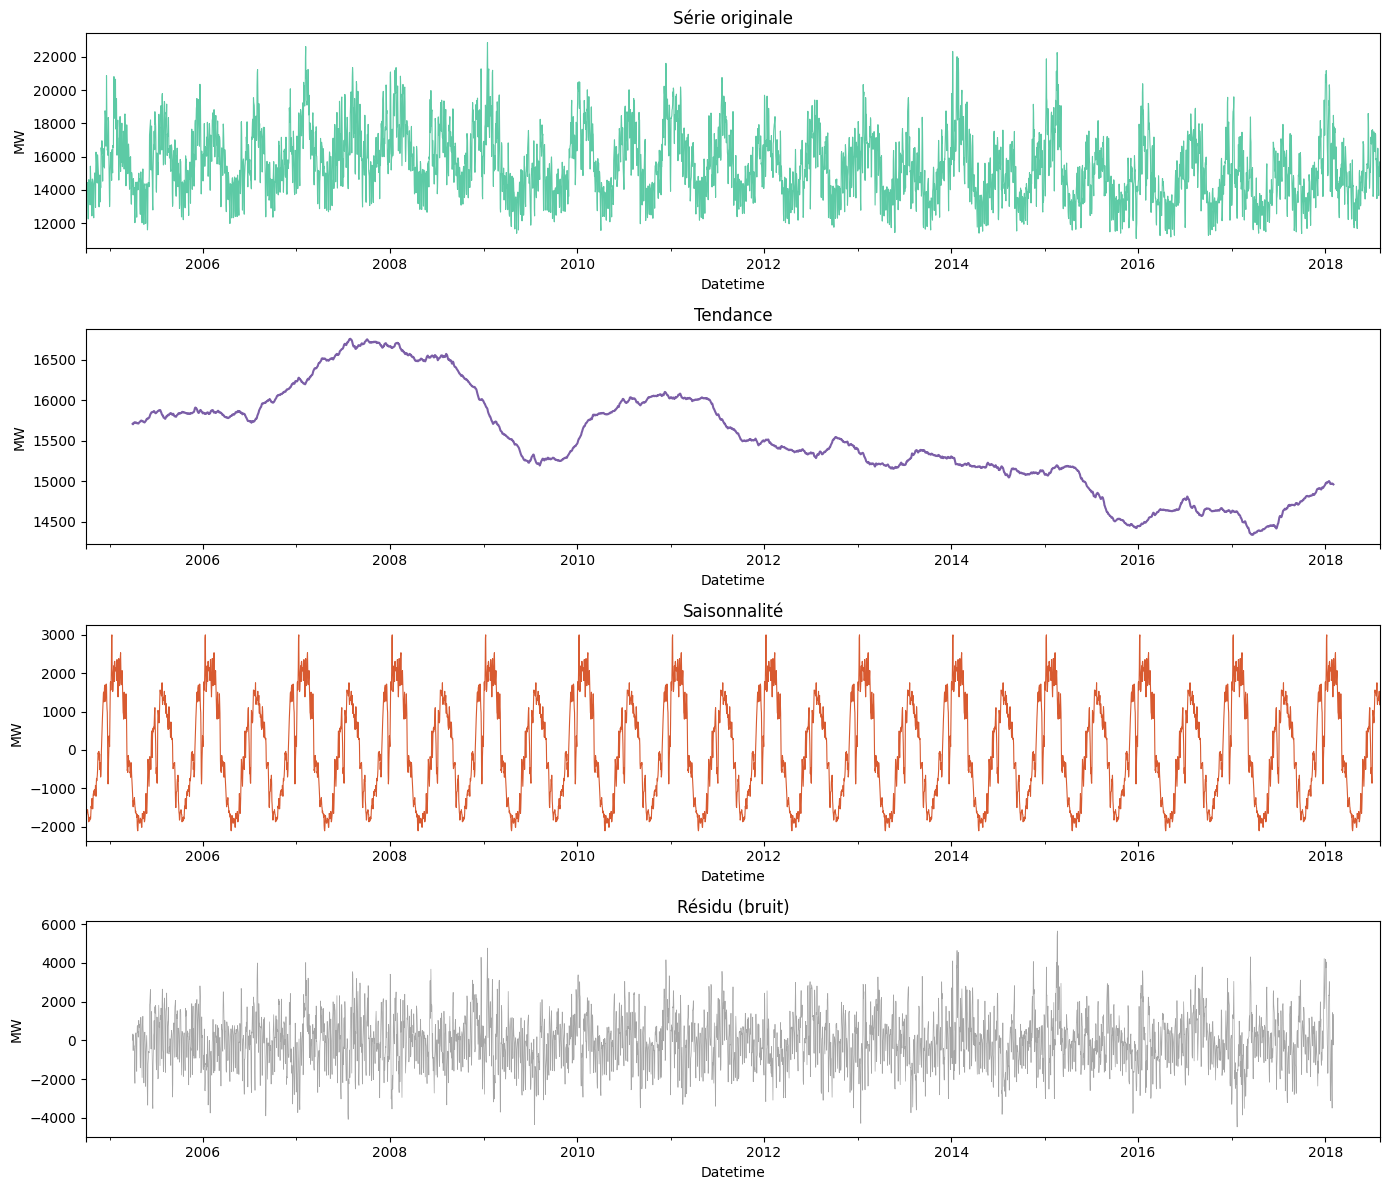

In [11]:
# On prend les données journalières pour la décomposition
df_daily = df['AEP_MW'].resample('D').mean().dropna()

# Décomposition en tendance + saisonnalité + résidu
decomposition = seasonal_decompose(df_daily, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

decomposition.observed.plot(ax=axes[0], color='#5DCAA5', linewidth=0.8)
axes[0].set_title("Série originale")
axes[0].set_ylabel("MW")

decomposition.trend.plot(ax=axes[1], color='#7B5EA7', linewidth=1.5)
axes[1].set_title("Tendance")
axes[1].set_ylabel("MW")

decomposition.seasonal.plot(ax=axes[2], color='#D85A30', linewidth=0.8)
axes[2].set_title("Saisonnalité")
axes[2].set_ylabel("MW")

decomposition.resid.plot(ax=axes[3], color='gray', linewidth=0.5, alpha=0.7)
axes[3].set_title("Résidu (bruit)")
axes[3].set_ylabel("MW")

plt.tight_layout()
plt.show()